# 인공지능 모델 학습 및 성능 비교

저장된 팀 후보 모델을 공용 Validation 데이터에서 동일한 기준으로 재평가하고, 최종 XGBoost의 운영 Threshold 0.38을 재현한 뒤 Test 성능을 1회 평가합니다. Test 데이터는 모델이나 Threshold 선택에 사용하지 않습니다.

## 1. 환경 설정과 데이터 로드

- Train / Validation / Test = 60% / 20% / 20%
- 층화 분할 및 `random_state=42`
- Target: 기준일 이후 90일 동안 정상 재구매가 없으면 `churn=1`

In [1]:
from pathlib import Path
import hashlib, json, warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from src.features import make_snapshot

warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'preprocessed').exists())
DATA = ROOT / 'data' / 'preprocessed'
ARTIFACTS = ROOT / 'artifacts'
FIGURES = ROOT / 'reports' / 'figures' / 'training'
ARTIFACTS.mkdir(exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

def load_split(name):
    return (pd.read_csv(DATA / f'X_{name}.csv'),
            pd.read_csv(DATA / f'y_{name}.csv')['churn'].astype(int))

X_train, y_train = load_split('train')
X_val, y_val = load_split('val')
X_test, y_test = load_split('test')
print('ROOT:', ROOT)
print('Train / Validation / Test:', len(X_train), len(X_val), len(X_test))
print('Features:', list(X_train.columns))

ROOT: D:\SKN_AI\Project2
Train / Validation / Test: 2592 864 864
Features: ['net_revenue', 'recency_days', 'frequency', 'distinct_products', 'tenure_days', 'avg_days_between_orders', 'is_low_value', 'is_uk', 'has_return', 'recent_activity_ratio']


## 2. 저장된 최종 모델의 FP·FN 고객군 분석

전처리 이전 고객 Feature를 동일한 분할 규칙으로 복원해 TP·TN·FP·FN 고객군의 행동 차이를 비교합니다. 고객 ID는 모델 입력과 저장 결과에서 제외되어 있으므로 개인 식별 사례가 아닌 고객군 단위 분석입니다.

recency_days                 frequency                 \
                  count     mean median     count    mean median   
error_type                                                         
FN                   60   47.200   28.5        60   9.267    8.5   
FP                  217  173.336  159.0       217   4.217    4.0   
TN                  220   39.336   25.0       220  19.850   13.0   
TP                  367  207.850  222.0       367   3.270    2.0   

           distinct_products                 net_revenue                      \
                       count     mean median       count      mean    median   
error_type                                                                     
FN                        60  102.683   80.5          60  2916.974  2134.850   
FP                       217   59.475   41.0         217  1255.110   823.390   
TN                       220  190.527  139.0         220  8353.542  4288.815   
TP                       367   41.398   28.0         367  1037.950   516.280   

           avg_days_between_orders                   recent_activity_ratio  \
                             count     mean   median                 count   
error_type                                                                   
FN                              60   46.981   46.750                    60   
FP                             217  129.837  110.200                   217   
TN                             220   36.776   35.286                   220   
TP                             367  161.339  135.250                   367   

                          
             mean median  
error_type                
FN          0.327  0.174  
FP          0.109  0.000  
TN          0.220  0.152  
TP          0.101  0.000

,recency_band,actual,customers,error_rate
0,0-30,0,139,0.122
1,0-30,1,54,0.556
2,31-90,0,107,0.383
3,31-90,1,65,0.292
4,91-180,0,103,0.699
5,91-180,1,92,0.109
6,181-365,0,88,0.989
7,181-365,1,216,0.005


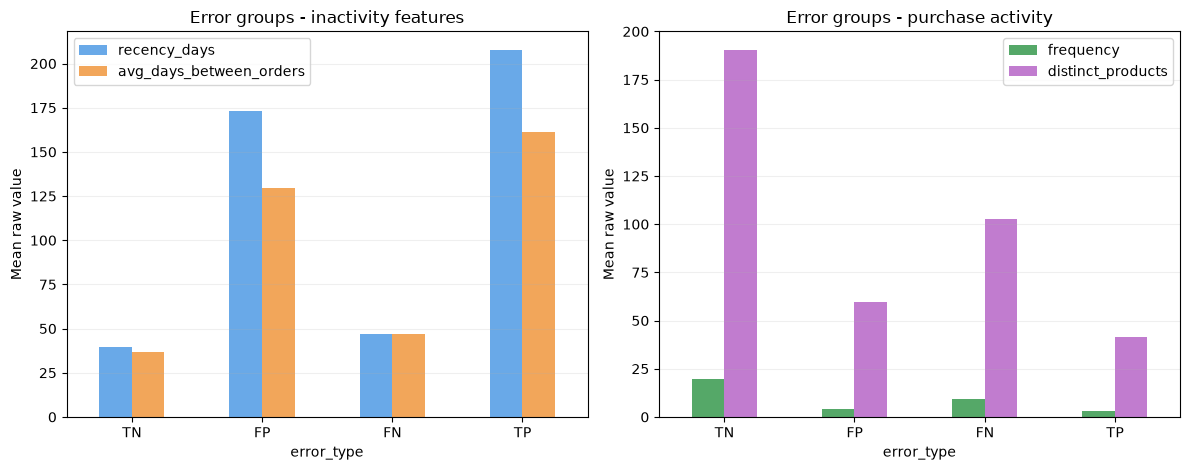

In [2]:
FINAL_PATH = ROOT / 'models' / 'final' / 'model_final.joblib'
final_model = joblib.load(FINAL_PATH)
baseline = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
baseline_test_proba = baseline.predict_proba(X_test)[:, 1]
final_test_proba = final_model.predict_proba(X_test)[:, 1]
pred = (final_test_proba >= 0.38).astype(int)
CUTOFF = pd.Timestamp('2011-09-10')
RAW_FEATURES = ['recency_days','frequency','distinct_products','net_revenue','tenure_days',
                'avg_order_value','is_uk','avg_days_between_orders','has_return','recent_activity_ratio']
snapshot = make_snapshot(CUTOFF, window=90)
X_raw, y_raw = snapshot[RAW_FEATURES], snapshot['churn']
X_raw_trainval, X_raw_test, y_raw_trainval, y_raw_test = train_test_split(
    X_raw, y_raw, test_size=.20, stratify=y_raw, random_state=42)
X_raw_train, X_raw_val, y_raw_train, y_raw_val = train_test_split(
    X_raw_trainval, y_raw_trainval, test_size=.25, stratify=y_raw_trainval, random_state=42)
assert np.array_equal(y_raw_test.to_numpy(), y_test.to_numpy())
error = X_raw_test.reset_index(drop=True).copy()
error['actual'] = y_test.to_numpy()
error['predicted'] = pred
error['error_type'] = np.select(
    [(error.actual==1)&(error.predicted==1),(error.actual==0)&(error.predicted==0),
     (error.actual==0)&(error.predicted==1),(error.actual==1)&(error.predicted==0)],
    ['TP','TN','FP','FN'], default='UNKNOWN')
profile_cols = ['recency_days','frequency','distinct_products','net_revenue','avg_days_between_orders','recent_activity_ratio']
error_profile = error.groupby('error_type')[profile_cols].agg(['count','mean','median']).round(3)
display(error_profile)
error.groupby('error_type')[profile_cols].mean().reset_index().to_csv(
    ARTIFACTS/'error_analysis.csv', index=False, encoding='utf-8-sig')

error['recency_band'] = pd.cut(error.recency_days, [-1,30,90,180,365], labels=['0-30','31-90','91-180','181-365'])
error['is_error'] = (error.actual != error.predicted).astype(int)
recency_error = error.groupby(['recency_band','actual'], observed=False).agg(
    customers=('is_error','size'), error_rate=('is_error','mean')).reset_index()
display(recency_error.round(3))

means = error.groupby('error_type')[['recency_days','avg_days_between_orders','frequency','distinct_products']].mean().reindex(['TN','FP','FN','TP'])
fig, axes = plt.subplots(1,2,figsize=(12,4.8))
means[['recency_days','avg_days_between_orders']].plot.bar(ax=axes[0],rot=0,color=['#69a9e8','#f2a65a'])
means[['frequency','distinct_products']].plot.bar(ax=axes[1],rot=0,color=['#55a868','#c17ccf'])
axes[0].set(title='Error groups - inactivity features',ylabel='Mean raw value')
axes[1].set(title='Error groups - purchase activity',ylabel='Mean raw value')
for ax in axes: ax.grid(axis='y',alpha=.2)
fig.tight_layout(); fig.savefig(FIGURES/'error_group_profiles.png',dpi=170); plt.show()

## 3. 저장된 최종 모델의 확률 보정 점검

ROC-AUC는 고객의 위험 순위 성능이고, Brier Score와 Calibration Curve는 출력 확률이 실제 발생률과 얼마나 가까운지 확인합니다. 확률 보정을 별도로 학습하지 않았으므로 ROI에서는 시나리오 추정치로만 사용해야 합니다.

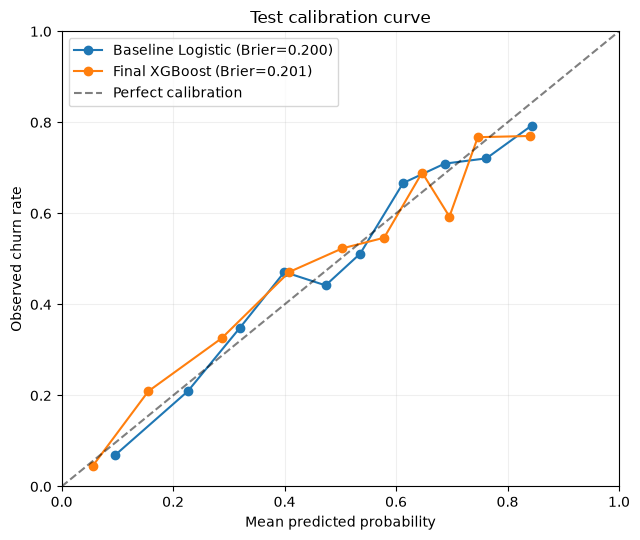

,model,brier_score,mean_predicted_probability,actual_churn_rate
0,Baseline Logistic,0.2003,0.4956,0.4942
1,Final XGBoost,0.2007,0.4919,0.4942


In [3]:
calibration_rows = []
fig, ax = plt.subplots(figsize=(6.5,5.5))
for name, probability in [('Baseline Logistic',baseline_test_proba),('Final XGBoost',final_test_proba)]:
    brier = brier_score_loss(y_test, probability)
    observed, predicted_mean = calibration_curve(y_test, probability, n_bins=10, strategy='quantile')
    calibration_rows.append({'model':name,'brier_score':brier,'mean_predicted_probability':probability.mean(),'actual_churn_rate':y_test.mean()})
    ax.plot(predicted_mean,observed,marker='o',label=f'{name} (Brier={brier:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=.5,label='Perfect calibration')
ax.set(xlabel='Mean predicted probability',ylabel='Observed churn rate',title='Test calibration curve',xlim=(0,1),ylim=(0,1))
ax.legend(); ax.grid(alpha=.2); fig.tight_layout()
fig.savefig(FIGURES/'calibration_curve.png',dpi=170); plt.show()
calibration_metrics = pd.DataFrame(calibration_rows)
calibration_metrics.to_csv(ARTIFACTS/'calibration_metrics.csv',index=False,encoding='utf-8-sig')
display(calibration_metrics.round(4))

## 4. 공통 평가 함수와 후보 모델 로드

후보마다 확률 분포가 다르므로 공통 규칙을 적용합니다. Threshold 0.20~0.70을 0.01 간격으로 확인하고, Recall 0.85 이상인 지점 중 F1이 최대인 값을 각 후보의 운영점으로 사용합니다.

In [4]:
THRESHOLDS = np.arange(0.20, 0.701, 0.01)

def unwrap(obj):
    if not isinstance(obj, dict):
        return obj, None
    return obj['model'], obj.get('feature_names') or obj.get('input_features')

def proba(model, X, features=None):
    if features is None and hasattr(model, 'feature_names_in_'):
        features = list(model.feature_names_in_)
    return model.predict_proba(X if features is None else X[list(features)])[:, 1]

def evaluate(y, probability, threshold):
    pred = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {'threshold': float(threshold), 'accuracy': accuracy_score(y, pred),
            'precision': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred), 'f1': f1_score(y, pred),
            'roc_auc': roc_auc_score(y, probability),
            'pr_auc': average_precision_score(y, probability),
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}

def best_threshold(y, probability, recall_floor):
    rows = [evaluate(y, probability, t) for t in THRESHOLDS]
    valid = [r for r in rows if r['recall'] >= recall_floor]
    return round(max(valid, key=lambda r: (r['f1'], r['threshold']))['threshold'], 2)

dummy = DummyClassifier(strategy='prior', random_state=42).fit(X_train, y_train)
baseline = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
candidates = {'Dummy (prior)': (dummy, None), 'Baseline Logistic': (baseline, None)}
paths = {'LightGBM (hyn)': 'models/hyn/model_final.joblib',
         'XGBoost (jhd)': 'models/jhd/model_final.joblib',
         'RandomForest (kmk)': 'models/kmk/model_final.joblib',
         'Logistic tuned (ksj)': 'models/ksj/model_final.joblib',
         'RandomForest tuned (lsy)': 'models/lsy/model_final.joblib'}
for name, path in paths.items():
    candidates[name] = unwrap(joblib.load(ROOT / path))
print('후보 수:', len(candidates))

후보 수: 7


## 5. Validation 성능 비교

ROC-AUC와 PR-AUC는 확률 순위의 판별력을, Recall·Precision·F1은 공통 운영점에서의 분류 성능을 보여줍니다.

  File "C:\Users\mk\miniforge3\envs\pystudy_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,model,threshold,recall,precision,f1,roc_auc,pr_auc
0,Dummy (prior),0.50,0.0000,0.0000,0.0000,0.5000,0.4942
1,Baseline Logistic,0.35,0.8712,0.6179,0.7230,0.7595,0.7308
2,LightGBM (hyn),0.45,0.8595,0.6439,0.7362,0.7748,0.7469
3,XGBoost (jhd),0.38,0.8571,0.6489,0.7386,0.7669,0.7350
4,RandomForest (kmk),0.35,0.8923,0.6256,0.7355,0.7672,0.7394
5,Logistic tuned (ksj),0.37,0.8501,0.6291,0.7231,0.7571,0.7303
6,RandomForest tuned (lsy),0.33,0.8899,0.6271,0.7357,0.7568,0.7267


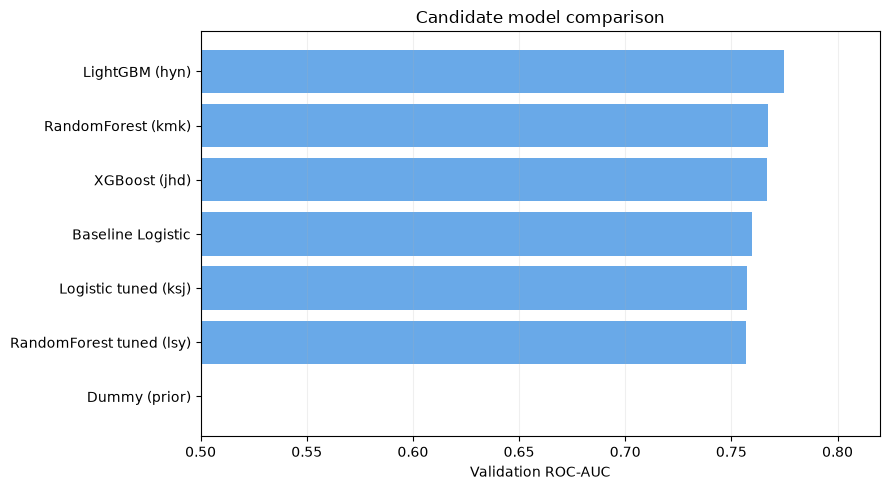

In [5]:
validation_rows, validation_probas = [], {}
for name, (model, features) in candidates.items():
    p = proba(model, X_val, features)
    validation_probas[name] = p
    t = 0.50 if name == 'Dummy (prior)' else best_threshold(y_val, p, 0.85)
    validation_rows.append({'split': 'validation', 'model': name, **evaluate(y_val, p, t)})
validation = pd.DataFrame(validation_rows)
display(validation[['model','threshold','recall','precision','f1','roc_auc','pr_auc']].round(4))

ordered = validation.sort_values('roc_auc')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ordered['model'], ordered['roc_auc'], color='#69a9e8')
ax.set(xlabel='Validation ROC-AUC', xlim=(0.5, 0.82), title='Candidate model comparison')
ax.grid(axis='x', alpha=.2); fig.tight_layout()
fig.savefig(FIGURES / 'validation_model_comparison.png', dpi=170)
plt.show()

## 6. 최종 XGBoost와 Threshold 0.38 재현

최종 모델은 Recall 0.85 이상인 Validation 후보 중 F1이 최대인 Threshold를 선택합니다. 이 규칙으로 0.38이 재현되어야 하며, Test를 보고 변경하지 않습니다.

재현된 Threshold: 0.38


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,0.38,0.7002,0.6489,0.8571,0.7386,0.7669,0.735,239,198,61,366


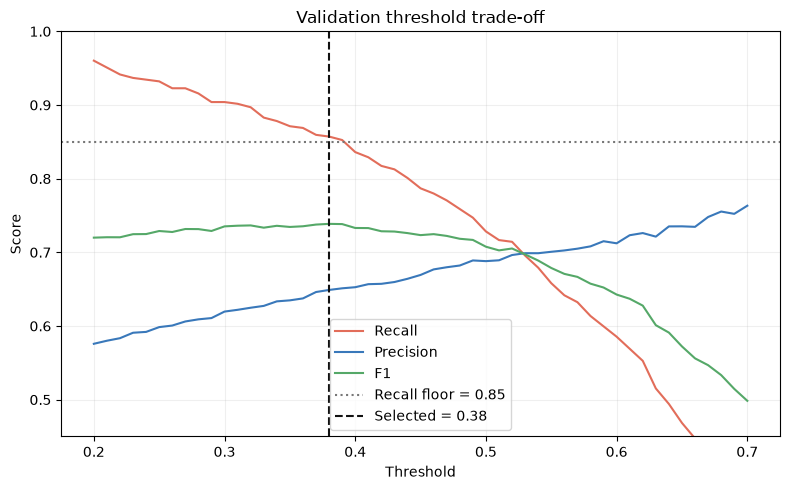

In [6]:
FINAL_PATH = ROOT / 'models' / 'final' / 'model_final.joblib'
final_model = joblib.load(FINAL_PATH)
final_val_proba = proba(final_model, X_val)
FINAL_THRESHOLD = best_threshold(y_val, final_val_proba, 0.85)
assert FINAL_THRESHOLD == 0.38
val_final = evaluate(y_val, final_val_proba, FINAL_THRESHOLD)
print('재현된 Threshold:', FINAL_THRESHOLD)
display(pd.DataFrame([val_final]).round(4))

scan = pd.DataFrame([evaluate(y_val, final_val_proba, t) for t in THRESHOLDS])
fig, ax = plt.subplots(figsize=(8, 5))
for col, color in [('recall','#e26d5a'),('precision','#3978ba'),('f1','#55a868')]:
    ax.plot(scan.threshold, scan[col], label=col.title(), color=color)
ax.axhline(.85, color='#777', linestyle=':', label='Recall floor = 0.85')
ax.axvline(FINAL_THRESHOLD, color='#111', linestyle='--', label='Selected = 0.38')
ax.set(xlabel='Threshold', ylabel='Score', ylim=(.45,1), title='Validation threshold trade-off')
ax.legend(); ax.grid(alpha=.2); fig.tight_layout()
fig.savefig(FIGURES / 'threshold_tradeoff.png', dpi=170)
plt.show()

## 7. 최종 Test 평가

Validation에서 확정한 XGBoost와 Threshold 0.38을 Test 864명에 한 번 적용합니다. 기준 모델은 기본 Threshold 0.5의 Logistic Regression입니다.

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Baseline Logistic,0.50,0.6829,0.6751,0.6909,0.6829,0.7544,0.7261,295,142,132,295
1,Final XGBoost,0.38,0.6794,0.6284,0.8595,0.7260,0.7525,0.7040,220,217,60,367


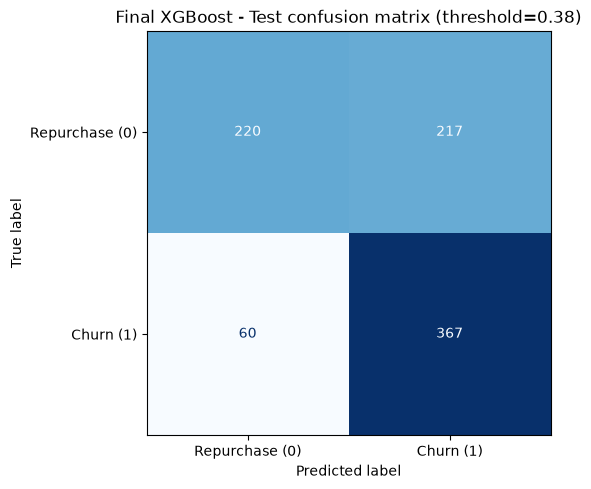

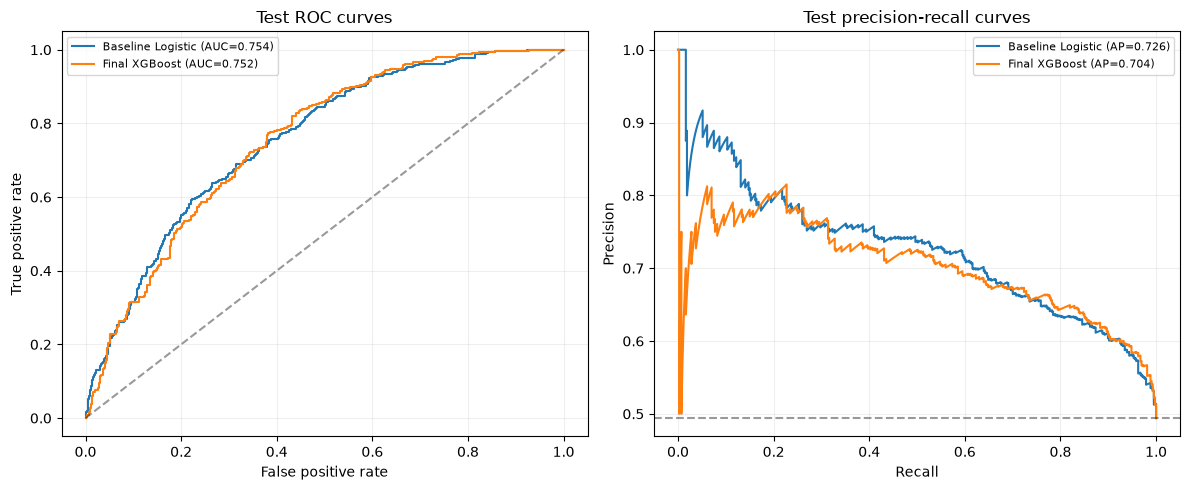

In [7]:
baseline_test_proba = proba(baseline, X_test)
final_test_proba = proba(final_model, X_test)
test_rows = [
    {'split':'test','model':'Baseline Logistic', **evaluate(y_test, baseline_test_proba, .50)},
    {'split':'test','model':'Final XGBoost', **evaluate(y_test, final_test_proba, FINAL_THRESHOLD)}]
test_results = pd.DataFrame(test_rows)
display(test_results[['model','threshold','accuracy','precision','recall','f1','roc_auc','pr_auc','tn','fp','fn','tp']].round(4))

pred = (final_test_proba >= FINAL_THRESHOLD).astype(int)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test,pred), display_labels=['Repurchase (0)','Churn (1)']).plot(ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Final XGBoost - Test confusion matrix (threshold=0.38)')
fig.tight_layout(); fig.savefig(FIGURES/'final_confusion_matrix.png',dpi=170); plt.show()

fig, axes = plt.subplots(1,2,figsize=(12,5))
for name,p in [('Baseline Logistic',baseline_test_proba),('Final XGBoost',final_test_proba)]:
    fpr,tpr,_=roc_curve(y_test,p); precision,recall,_=precision_recall_curve(y_test,p)
    axes[0].plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,p):.3f})')
    axes[1].plot(recall,precision,label=f'{name} (AP={average_precision_score(y_test,p):.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=.4); axes[1].axhline(y_test.mean(),color='k',ls='--',alpha=.4)
axes[0].set(title='Test ROC curves',xlabel='False positive rate',ylabel='True positive rate')
axes[1].set(title='Test precision-recall curves',xlabel='Recall',ylabel='Precision')
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=.2)
fig.tight_layout(); fig.savefig(FIGURES/'test_roc_pr_curves.png',dpi=170); plt.show()

## 8. 모델 해석과 산출물 저장

Permutation Importance는 Feature를 섞었을 때 ROC-AUC 감소량을 측정합니다. 인과관계가 아니며 상관된 Feature 사이에서는 중요도가 분산될 수 있습니다.

,feature,importance_mean,importance_std
5,avg_days_between_orders,0.0441,0.0112
1,recency_days,0.0385,0.0056
0,net_revenue,0.0169,0.0054
3,distinct_products,0.0157,0.0056
4,tenure_days,0.0070,0.0043
2,frequency,0.0029,0.0015
9,recent_activity_ratio,0.0013,0.0012
8,has_return,0.0009,0.0012
6,is_low_value,0.0001,0.0002
7,is_uk,-0.0000,0.0000


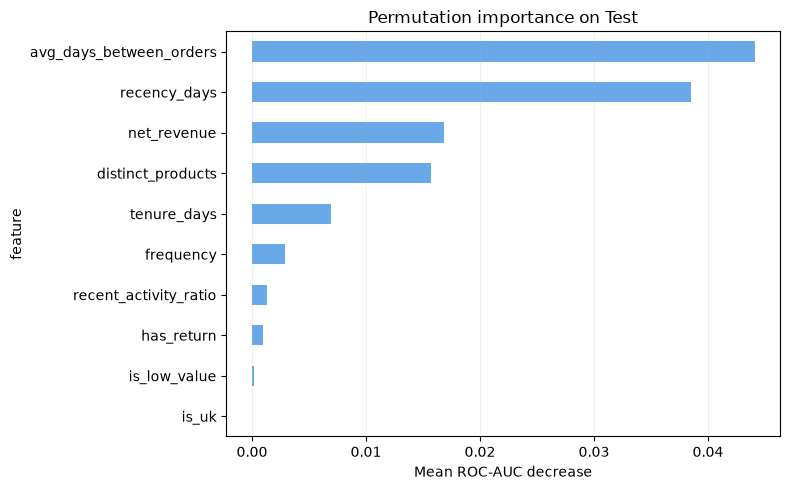

저장 완료: D:\SKN_AI\Project2\artifacts
새 프로세스 재로딩에 사용할 단일 Pipeline: D:\SKN_AI\Project2\models\final\churn_pipeline.joblib


In [8]:
pi = permutation_importance(final_model, X_test, y_test, scoring='roc_auc', n_repeats=20, random_state=42, n_jobs=1)
importance = pd.DataFrame({'feature':X_test.columns,'importance_mean':pi.importances_mean,'importance_std':pi.importances_std}).sort_values('importance_mean',ascending=False)
display(importance.round(4))
fig, ax = plt.subplots(figsize=(8,5))
importance.sort_values('importance_mean').plot.barh(x='feature',y='importance_mean',legend=False,ax=ax,color='#69a9e8')
ax.set(title='Permutation importance on Test',xlabel='Mean ROC-AUC decrease'); ax.grid(axis='x',alpha=.2)
fig.tight_layout(); fig.savefig(FIGURES/'permutation_importance.png',dpi=170); plt.show()

metrics_all = pd.concat([validation, test_results], ignore_index=True)
metrics_all.to_csv(ARTIFACTS/'metrics.csv',index=False,encoding='utf-8-sig')
importance.to_csv(ARTIFACTS/'permutation_importance.csv',index=False,encoding='utf-8-sig')
preprocessor = joblib.load(DATA / 'preprocessor.pkl')
deployment_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', final_model)])
PIPELINE_PATH = ROOT / 'models' / 'final' / 'churn_pipeline.joblib'
joblib.dump(deployment_pipeline, PIPELINE_PATH, compress=3)
metadata = {'model_name':type(final_model).__name__,'model_version':'1.0','trained_at':'2026-07-21',
 'model_path':'models/final/model_final.joblib',
 'model_sha256':hashlib.sha256(FINAL_PATH.read_bytes()).hexdigest(),
 'deployment_pipeline_path':'models/final/churn_pipeline.joblib',
 'deployment_pipeline_sha256':hashlib.sha256(PIPELINE_PATH.read_bytes()).hexdigest(),
 'threshold':FINAL_THRESHOLD,
 'target_definition':'기준일 이후 90일 동안 정상 재구매가 관측되지 않음',
 'positive_class':1,
 'threshold_selection':{'split':'validation','scan_range':[.20,.70],'step':.01,
   'rule':'maximum F1 among thresholds with recall >= 0.85','reproduced_threshold':FINAL_THRESHOLD},
 'primary_metric':'recall','random_state':42,'features':list(X_train.columns),
 'hyperparameters':final_model.get_params(),
 'data_split':{'train':len(X_train),'validation':len(X_val),'test':len(X_test)},
 'generated_at':datetime.now(timezone.utc).isoformat()}
metadata['hyperparameters']['missing'] = None
(ARTIFACTS/'model_metadata.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2,default=str),encoding='utf-8')

reloaded = joblib.load(FINAL_PATH)
assert np.allclose(proba(reloaded,X_test.iloc[:5]),final_test_proba[:5])
print('저장 완료:', ARTIFACTS)
print('새 프로세스 재로딩에 사용할 단일 Pipeline:', PIPELINE_PATH)

## 9. 결론

XGBoost가 모든 지표에서 최고인 것은 아닙니다. LightGBM은 Validation ROC-AUC와 PR-AUC가 더 높고 기본 Logistic은 Test ROC-AUC와 PR-AUC가 근소하게 높습니다. 최종 XGBoost 0.38은 Recall 중심의 저비용 리텐션 캠페인이라는 운영 목적 아래, Validation Recall 조건을 만족하면서 F1 균형이 가장 좋아 선택한 운영안입니다.